# **TWITTER SENTIMENT ANALYSIS - PROJECT PREDICTION SENTIMENT ANALYSIS**

# Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import warnings
import tabulate

# Regular Expression
import re

# Text Manipulation --> Natural Languages Tool Kit
import nltk
# Tokenizer, word_tokenizer
from nltk.tokenize import word_tokenize
# Stopwords
from nltk.corpus import stopwords
# To Stemming
from nltk.stem import WordNetLemmatizer


# WordCloud --> To Show All Words in dataset
from wordcloud import WordCloud as wc

pd.set_option('display.max_colwidth', 200)
warnings.filterwarnings('ignore', category=DeprecationWarning)

%matplotlib inline

In [2]:
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\USER\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

# Gathering Data

In [3]:
df_train = pd.read_csv('../data/train_E6oV3lV.csv')
df_test = pd.read_csv('../data/test_tweets_anuFYb8.csv')

display(df_train.head(3))  # With labels
display(df_test.head(3))  # Without labels

print(f'Train Shape : {df_train.shape}, Test Shape : {df_test.shape}')

,id,label,tweet
0,1,0,@user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction. #run
1,2,0,@user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx. #disapointed #getthanked
2,3,0,bihday your majesty


,id,tweet
0,31963,#studiolife #aislife #requires #passion #dedication #willpower to find #newmaterialsâ¦
1,31964,@user #white #supremacists want everyone to see the new â #birdsâ #movie â and hereâs why
2,31965,safe ways to heal your #acne!! #altwaystoheal #healthy #healing!!


Train Shape : (31962, 3), Test Shape : (17197, 2)


# Data Preparation

## Inspection Data

In [4]:
print(f'Labels: {df_train['label'].unique()}')  # [0,1]

print(f'{'='*30} VALUE COUNTS OF THIS LABELS {'='*30}')

print(f'Value Counts : \n{df_train['label'].value_counts()}')

labels_no = df_train[df_train['label'] == 0]
labels_yes = df_train[df_train['label'] == 1]

print(f'{'='*30}  LABELS  {'='*30}')
print(f'{'='*30} Label No {'='*30}')
print(labels_no.head(3).to_markdown())
print(f'{'='*30} Label Yes {'='*30}')
print(labels_yes.head(3).to_markdown())

Labels: [0 1]
============================== VALUE COUNTS OF THIS LABELS ==============================
Value Counts : 
label
0    29720
1     2242
Name: count, dtype: int64
==============================  LABELS  ==============================
============================== Label No ==============================
|    |   id |   label | tweet                                                                                                                      |
|---:|-----:|--------:|:---------------------------------------------------------------------------------------------------------------------------|
|  0 |    1 |       0 | @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run                      |
|  1 |    2 |       0 | @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked |
|  2 |    3 |       0 | bihday your majesty                                             

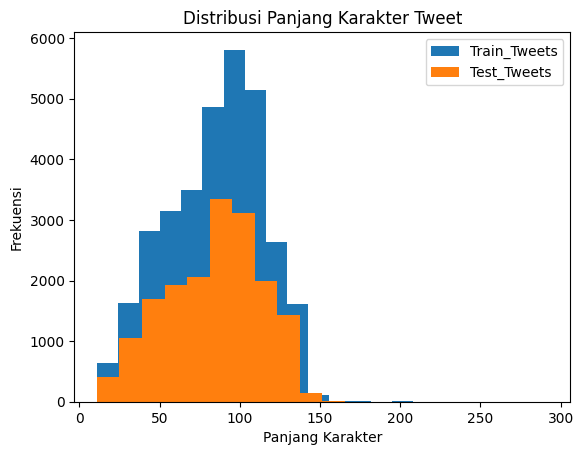

In [5]:
len_train = df_train['tweet'].str.len()
len_test = df_test['tweet'].str.len()

plt.hist(len_train, bins=20, label='Train_Tweets')
plt.hist(len_test, bins=20, label='Test_Tweets')
plt.legend()
plt.title('Distribusi Panjang Karakter Tweet')
plt.xlabel('Panjang Karakter')
plt.ylabel('Frekuensi')
plt.show()

Meskipun data_train lebih banyak, tapi ternyata panjang karakter data_train maupun data_test hampir sama.

## Combine Train and Test Datasets

In [6]:
combine = pd.concat([df_train, df_test], ignore_index = True)
print(combine.shape)

(49159, 3)


# Preprocessing Data

### Cleaning Text

In [7]:
# Lower Case
combine['tweet'] = combine['tweet'].str.lower()

# Remove Mention & Link
combine['clean_text'] = combine['tweet'].str.replace(r'http\S+|www\S+|@\w+', '', regex=True)

# Regex 2: Removing Punctuation, Numbers, and Special Character
# Perhatikan kita menambahkan \.,!\?' ke dalam kurung siku
combine['clean_text'] = combine['clean_text'].str.replace(r'[^a-zA-Z#\.,!\?\'\s]', ' ', regex=True)

# Regex 3: Delete double space.
combine['clean_text'] = combine['clean_text'].str.replace(r'\s+', ' ', regex=True)

# 4. Tokenisasi with NLTK
combine['tokens'] = combine['clean_text'].apply(word_tokenize)

## Stemming

In [8]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

negation_words = {'no', 'not', 'nor', 'never', 'very'}
stop_words -= negation_words

combine['tokens'] = combine['tokens'].apply(
    lambda tokens: [lemmatizer.lemmatize(word)
                   for word in tokens
                   if word not in stop_words 
                    and len(word) > 2
                    and word != 'amp'
                   ]
)

### Join All tokens back (Detokenized)

In [9]:
combine['final_text'] = combine['tokens'].apply(lambda x: " ".join(x))

## The Most Common Words In The Entire Datasets --> For Stemmed_Split

In [10]:
def word_cloud(data):
    return wc(width=800, height=500, random_state=21, max_font_size=110).generate(data)

In [11]:
positive_labels = combine['final_text'][combine['label']== 0]
negative_labels = combine['final_text'][combine['label']== 1]

### All Datasets

In [12]:
all_words = ' '.join([text for text in combine['final_text']])
wordcloud = word_cloud(all_words)

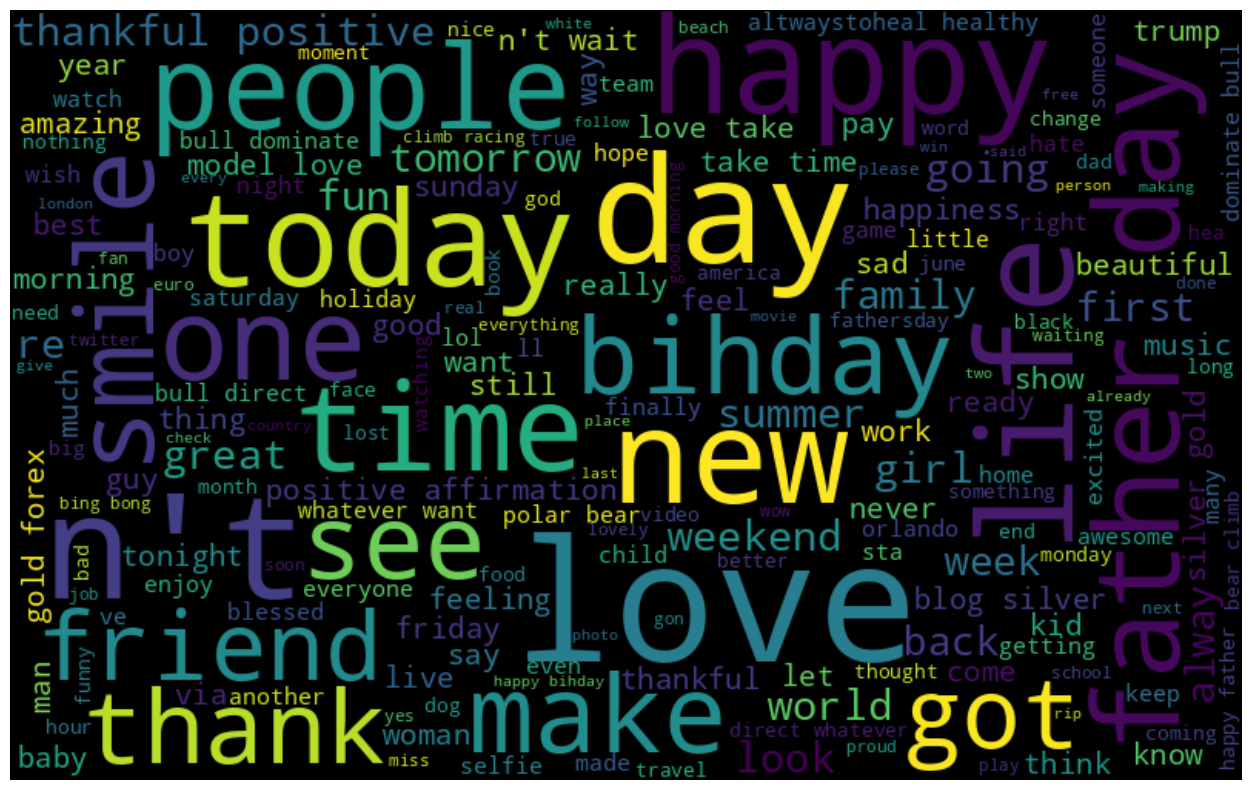

In [13]:
plt.figure(figsize=(16,10))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

### Positive Datasets

In [14]:
positive_words = ' '.join([text for text in positive_labels])
wordcloud_positive = word_cloud(positive_words)

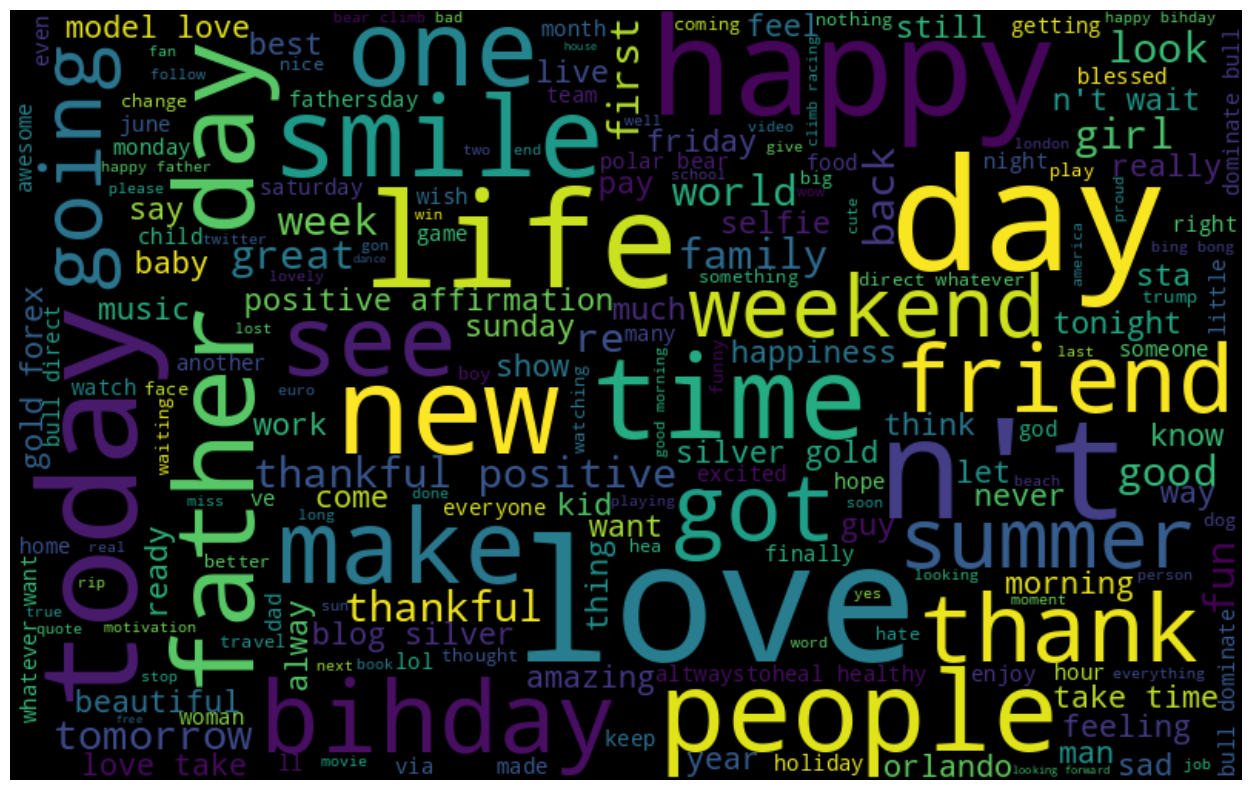

In [15]:
plt.figure(figsize=(16,10))
plt.imshow(wordcloud_positive,  interpolation='bilinear')
plt.axis('off')
plt.show()

Jika dilihat, ini sudah sesuai dengan kata-kata yang positif, seperti smile, love, thank, life, beauti,love u, friend.

### Negative Datasets

In [16]:
negative_words = ' '.join([text for text in negative_labels])
wordcloud_negative = word_cloud(negative_words)

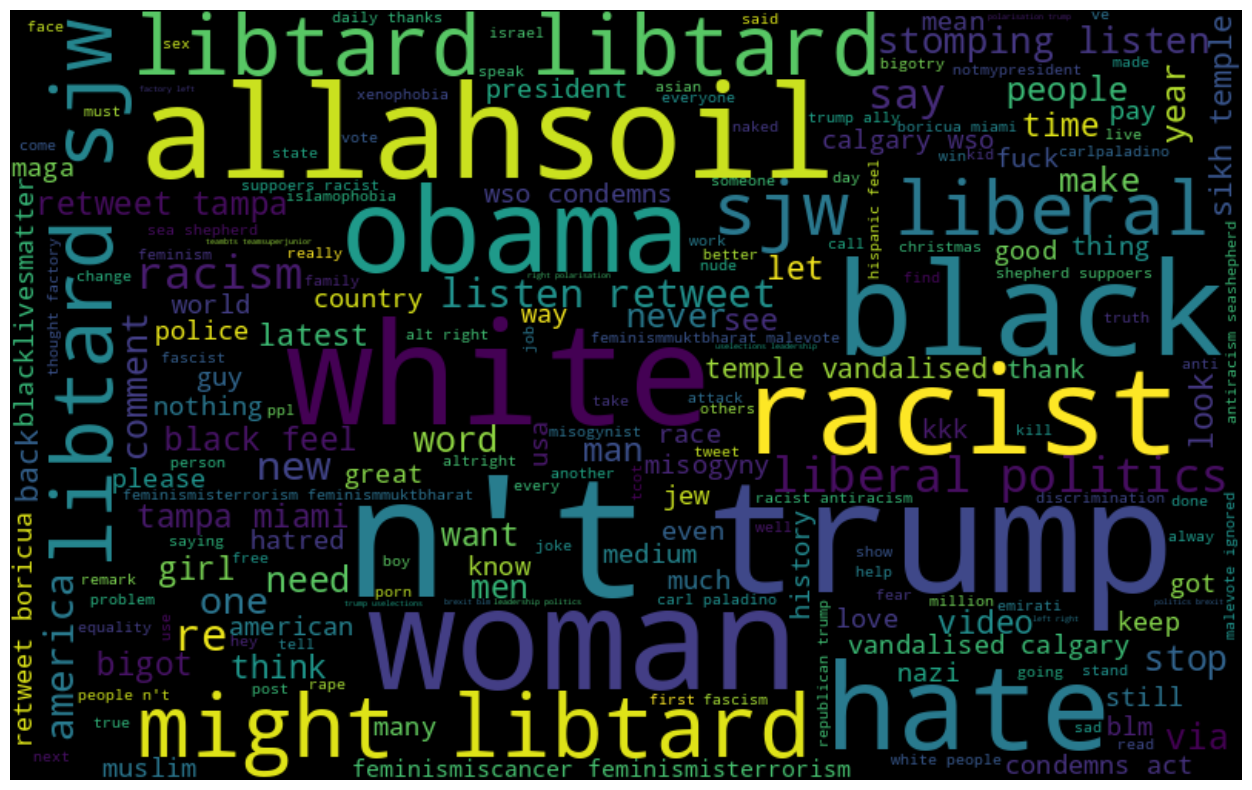

In [17]:
plt.figure(figsize=(16,10))
plt.imshow(wordcloud_negative, interpolation='bilinear')
plt.axis('off')
plt.show()           

Jika dilihat, data negatif juga sudah sesuai, seperti obama, trump, black, racist, hate, racism, america, dan lainnya, meskipun ada beberapa data yang masih termasuk kata positif.